# PET REMOTE SYSTEM_(1) DATA ANALISYS

```
CLAUDE
```

## 0. 라이브러리 설정

In [1]:
"""
반려동물 질병 데이터 탐색적 분석 (EDA)
Step-by-Step Data Analysis for Pet Disease Severity
"""

import numpy as np
import pandas as pd
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 통계
from scipy import stats
from scipy.stats import chi2_contingency, kruskal

# 설정
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. 데이터 생성 및 로드

In [2]:
# ================== STEP 1: 데이터 생성 및 로드 ==================

class DataGenerator:
    """테스트용 샘플 데이터 생성"""
    
    def __init__(self, data_path: str = "./dogwalk/2.라벨링데이터"):
        self.data_path = data_path
        
    def create_realistic_sample_data(self, n_samples: int = 500):
        """좀 더 현실적인 샘플 데이터 생성"""
        import random
        
        os.makedirs(self.data_path, exist_ok=True)
        
        # 품종별 특성 (실제 데이터에 기반한 가정)
        breed_characteristics = {
            'Golden Retriever': {'weight_range': (25, 35), 'hip_dysplasia_risk': 0.3},
            'Labrador': {'weight_range': (25, 36), 'hip_dysplasia_risk': 0.25},
            'Beagle': {'weight_range': (9, 11), 'hip_dysplasia_risk': 0.1},
            'Poodle': {'weight_range': (20, 32), 'hip_dysplasia_risk': 0.15},
            'Bulldog': {'weight_range': (18, 25), 'hip_dysplasia_risk': 0.4},
            'German Shepherd': {'weight_range': (30, 40), 'hip_dysplasia_risk': 0.35},
            'Yorkshire Terrier': {'weight_range': (2, 4), 'hip_dysplasia_risk': 0.05},
            'Boxer': {'weight_range': (25, 32), 'hip_dysplasia_risk': 0.2},
            'Dachshund': {'weight_range': (7, 14), 'hip_dysplasia_risk': 0.3},
            'Siberian Husky': {'weight_range': (20, 27), 'hip_dysplasia_risk': 0.15}
        }
        
        # 나이별 질병 위험도
        age_risk = lambda age: 0.05 if age < 2 else (0.1 if age < 5 else (0.2 if age < 8 else 0.4))
        
        # 클래스 분포 (현실적인 불균형)
        severity_weights = [0.5, 0.25, 0.15, 0.07, 0.03]  # 확률 가중치
        
        generated_data = []
        
        for i in range(n_samples):
            # 품종 선택
            breed = random.choice(list(breed_characteristics.keys()))
            breed_info = breed_characteristics[breed]
            
            # 나이와 체중 (품종별 특성 반영)
            age = random.triangular(1, 6, 15)  # 삼각분포: 6세 근처가 가장 많음
            weight = random.uniform(*breed_info['weight_range'])
            
            # 중증도 결정 (나이, 품종 위험도 고려)
            base_risk = age_risk(age) + breed_info['hip_dysplasia_risk']
            severity_probs = np.array(severity_weights) * (1 + base_risk)
            severity_probs = severity_probs / severity_probs.sum()
            severity = np.random.choice(5, p=severity_probs)
            
            # 기본 정보
            data = {
                'pet_id': f'PET_{i:04d}',
                'age': round(age, 1),
                'weight': round(weight, 1),
                'breed': breed,
                'severity': int(severity),
                'pose_features': {},
                'sensor_data': {}
            }
            
            # Pose features 생성 (질병 중증도에 따른 패턴)
            for j in range(13):
                # P12는 꼬리 끝 - 자주 가려짐
                if j == 12 and random.random() > 0.3:
                    continue
                    
                # 다른 관절들도 가끔 가려짐
                if random.random() > 0.95:
                    continue
                
                # 정상 관절 위치 (기준점)
                base_x = 100 + j * 20
                base_y = 100 + (j % 4) * 30
                
                # 중증도에 따른 비정상 패턴
                if severity >= 3:  # 심각한 경우
                    # 비대칭성 증가, 관절 위치 이상
                    deviation_x = random.gauss(0, 15 * (1 + severity/2))
                    deviation_y = random.gauss(0, 15 * (1 + severity/2))
                    # 좌우 다리 관절에 비대칭 추가
                    if j in [1, 2, 3]:  # 왼쪽 다리
                        deviation_x += severity * 5
                    elif j in [4, 5, 6]:  # 오른쪽 다리
                        deviation_x -= severity * 5
                else:
                    deviation_x = random.gauss(0, 5)
                    deviation_y = random.gauss(0, 5)
                
                data['pose_features'][f'P{j}'] = {
                    'x': round(base_x + deviation_x, 2),
                    'y': round(base_y + deviation_y, 2),
                    'confidence': round(max(0.5, min(1.0, 0.95 - severity * 0.1 + random.gauss(0, 0.05))), 3)
                }
            
            # Sensor data 생성 (100 time points)
            time_points = 100
            
            # 정상 보행 패턴
            t = np.linspace(0, 4*np.pi, time_points)
            
            if severity == 0:  # 정상
                acc_pattern = np.sin(t) * 2
                gyro_pattern = np.cos(t) * 1
                noise_level = 0.5
            elif severity <= 2:  # 경미-중등도
                # 불규칙한 보행
                acc_pattern = np.sin(t) * 2 + np.sin(3*t) * severity
                gyro_pattern = np.cos(t) * 1 + np.cos(2*t) * severity/2
                noise_level = 1.0 * (1 + severity/4)
            else:  # 심각
                # 매우 불규칙한 패턴, 절뚝거림
                acc_pattern = np.sin(t) * 2 + np.sin(3*t) * severity + np.sin(5*t) * (severity-2)
                gyro_pattern = np.cos(t) * 1 + np.cos(2*t) * severity
                noise_level = 2.0 * severity/3
            
            # 3축 센서 데이터
            data['sensor_data'] = {
                'acc_x': (acc_pattern + np.random.normal(0, noise_level, time_points)).tolist(),
                'acc_y': (acc_pattern * 0.7 + np.random.normal(0, noise_level, time_points)).tolist(),
                'acc_z': (9.8 + acc_pattern * 0.3 + np.random.normal(0, noise_level * 0.5, time_points)).tolist(),
                'gyro_x': (gyro_pattern + np.random.normal(0, noise_level * 0.5, time_points)).tolist(),
                'gyro_y': (gyro_pattern * 0.8 + np.random.normal(0, noise_level * 0.5, time_points)).tolist(),
                'gyro_z': (gyro_pattern * 0.5 + np.random.normal(0, noise_level * 0.3, time_points)).tolist()
            }
            
            generated_data.append(data)
        
        # JSON 파일로 저장
        for i, data in enumerate(generated_data):
            filename = f'pet_data_{i:04d}.json'
            filepath = os.path.join(self.data_path, filename)
            with open(filepath, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2)
        
        print(f"✅ Generated {len(generated_data)} realistic sample files")
        
        # 분포 확인
        severity_dist = pd.Series([d['severity'] for d in generated_data]).value_counts().sort_index()
        print("\n📊 Severity distribution:")
        for sev, count in severity_dist.items():
            print(f"  Level {sev}: {count:3d} samples ({count/len(generated_data)*100:5.1f}%)")
        
        return generated_data

## 2. 데이터 로드 및 구조 파악

In [3]:
# ================== STEP 2: 데이터 로드 및 구조 파악 ==================

class DataLoader:
    """데이터 로드 및 기본 구조 파악"""
    
    def __init__(self, data_path: str = "./pet_data"):
        self.data_path = data_path
        self.raw_data = []
        self.df = None
        
    def load_and_parse(self):
        """JSON 파일 로드 및 DataFrame 변환"""
        
        # 디렉토리 체크
        if not os.path.exists(self.data_path):
            print("📁 데이터 디렉토리가 없습니다. 샘플 데이터를 생성합니다...")
            generator = DataGenerator(self.data_path)
            generator.create_realistic_sample_data(500)
        
        # JSON 파일 로드
        json_files = [f for f in os.listdir(self.data_path) if f.endswith('.json')]
        
        if not json_files:
            print("⚠️ JSON 파일이 없습니다. 샘플 데이터를 생성합니다...")
            generator = DataGenerator(self.data_path)
            generator.create_realistic_sample_data(500)
            json_files = [f for f in os.listdir(self.data_path) if f.endswith('.json')]
        
        print(f"📂 Found {len(json_files)} JSON files")
        
        # 데이터 로드
        for filename in json_files[:500]:  # 최대 500개만
            filepath = os.path.join(self.data_path, filename)
            with open(filepath, 'r') as f:
                data = json.load(f)
                self.raw_data.append(data)
        
        print(f"✅ Loaded {len(self.raw_data)} files successfully")
        
        # DataFrame으로 변환
        self.df = self._create_dataframe()
        return self.df
    
    def _create_dataframe(self):
        """JSON 데이터를 분석용 DataFrame으로 변환"""
        
        rows = []
        for data in self.raw_data:
            row = {
                'pet_id': data.get('pet_id'),
                'age': data.get('age'),
                'weight': data.get('weight'),
                'breed': data.get('breed'),
                'severity': data.get('severity')
            }
            
            # Pose features
            pose = data.get('pose_features', {})
            for i in range(13):
                key = f'P{i}'
                if key in pose:
                    row[f'{key}_x'] = pose[key].get('x')
                    row[f'{key}_y'] = pose[key].get('y')
                    row[f'{key}_conf'] = pose[key].get('confidence')
                else:
                    row[f'{key}_x'] = np.nan
                    row[f'{key}_y'] = np.nan
                    row[f'{key}_conf'] = np.nan
            
            # Sensor statistics
            sensor = data.get('sensor_data', {})
            for axis in ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']:
                values = sensor.get(axis, [])
                if values:
                    row[f'{axis}_mean'] = np.mean(values)
                    row[f'{axis}_std'] = np.std(values)
                    row[f'{axis}_max'] = np.max(values)
                    row[f'{axis}_min'] = np.min(values)
                else:
                    row[f'{axis}_mean'] = np.nan
                    row[f'{axis}_std'] = np.nan
                    row[f'{axis}_max'] = np.nan
                    row[f'{axis}_min'] = np.nan
            
            rows.append(row)
        
        df = pd.DataFrame(rows)
        print(f"✅ Created DataFrame with shape: {df.shape}")
        return df

## 3. 탐색적 데이터 분석 (EDA)

In [4]:
# ================== STEP 3: 탐색적 데이터 분석 (EDA) ==================

class ExploratoryDataAnalysis:
    """체계적인 EDA 수행"""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        
    def basic_info(self):
        """기본 정보 출력"""
        print("=" * 80)
        print("📊 DATASET OVERVIEW")
        print("=" * 80)
        
        print(f"\n1. Shape: {self.df.shape[0]} rows × {self.df.shape[1]} columns")
        
        print(f"\n2. Column Types:")
        print(f"   - Numeric: {len(self.numeric_cols)} columns")
        print(f"   - Categorical: {len(self.categorical_cols)} columns")
        
        print(f"\n3. Memory Usage: {self.df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        print("\n4. First 5 rows:")
        display_cols = ['pet_id', 'age', 'weight', 'breed', 'severity', 'P0_x', 'P0_y', 'acc_x_mean']
        print(self.df[display_cols].head())
        
    def target_distribution(self):
        """타겟 변수 (severity) 분석"""
        print("\n" + "=" * 80)
        print("🎯 TARGET VARIABLE ANALYSIS (Severity)")
        print("=" * 80)
        
        # 분포
        severity_counts = self.df['severity'].value_counts().sort_index()
        
        print("\n1. Distribution:")
        for sev, count in severity_counts.items():
            pct = count / len(self.df) * 100
            bar = '█' * int(pct/2)
            print(f"   Level {sev}: {count:3d} ({pct:5.1f}%) {bar}")
        
        # 클래스 불균형 비율
        imbalance_ratio = severity_counts.max() / severity_counts.min()
        print(f"\n2. Class Imbalance Ratio: {imbalance_ratio:.2f}x")
        print(f"   (Majority class has {imbalance_ratio:.1f} times more samples than minority)")
        
        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # 막대 그래프
        severity_counts.plot(kind='bar', ax=axes[0], color='steelblue')
        axes[0].set_title('Severity Level Distribution')
        axes[0].set_xlabel('Severity Level')
        axes[0].set_ylabel('Count')
        axes[0].grid(axis='y', alpha=0.3)
        
        # 파이 차트
        colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
        severity_counts.plot(kind='pie', ax=axes[1], colors=colors[:len(severity_counts)],
                            autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Severity Level Proportions')
        axes[1].set_ylabel('')
        
        plt.tight_layout()
        plt.show()
        
    def missing_value_analysis(self):
        """결측치 분석"""
        print("\n" + "=" * 80)
        print("🔍 MISSING VALUE ANALYSIS")
        print("=" * 80)
        
        # 결측치 계산
        missing_df = pd.DataFrame({
            'Column': self.df.columns,
            'Missing_Count': self.df.isnull().sum(),
            'Missing_Percent': self.df.isnull().sum() / len(self.df) * 100
        }).sort_values('Missing_Percent', ascending=False)
        
        # 결측치가 있는 컬럼만
        missing_df = missing_df[missing_df['Missing_Count'] > 0]
        
        if len(missing_df) > 0:
            print("\n1. Columns with missing values:")
            print(missing_df.head(10).to_string(index=False))
            
            # 관절별 결측치 패턴
            pose_missing = {}
            for i in range(13):
                x_missing = self.df[f'P{i}_x'].isnull().sum() / len(self.df) * 100
                pose_missing[f'P{i}'] = x_missing
            
            print("\n2. Missing pattern by joint points:")
            for joint, pct in sorted(pose_missing.items(), key=lambda x: x[1], reverse=True):
                if pct > 0:
                    bar = '█' * int(pct/2)
                    print(f"   {joint:3s}: {pct:5.1f}% {bar}")
            
            # 시각화
            if len(missing_df) > 0:
                plt.figure(figsize=(12, 6))
                top_missing = missing_df.head(20)
                plt.barh(range(len(top_missing)), top_missing['Missing_Percent'])
                plt.yticks(range(len(top_missing)), top_missing['Column'])
                plt.xlabel('Missing Percentage (%)')
                plt.title('Top 20 Columns with Missing Values')
                plt.grid(axis='x', alpha=0.3)
                
                # 50% 임계선
                plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
                plt.legend()
                plt.tight_layout()
                plt.show()
        else:
            print("\n✅ No missing values found!")
    
    def feature_statistics(self):
        """주요 피처 통계"""
        print("\n" + "=" * 80)
        print("📈 FEATURE STATISTICS")
        print("=" * 80)
        
        # 1. 기본 정보 통계
        print("\n1. Pet Information Statistics:")
        info_stats = self.df[['age', 'weight']].describe()
        print(info_stats)
        
        # 2. 품종 분포
        print("\n2. Breed Distribution:")
        breed_counts = self.df['breed'].value_counts()
        for breed, count in breed_counts.head(10).items():
            pct = count / len(self.df) * 100
            print(f"   {breed:20s}: {count:3d} ({pct:5.1f}%)")
        
        # 3. 센서 데이터 통계
        print("\n3. Sensor Data Statistics:")
        sensor_cols = [col for col in self.df.columns if any(s in col for s in ['acc_', 'gyro_']) and '_mean' in col]
        sensor_stats = self.df[sensor_cols].describe()
        print(sensor_stats)
        
    def severity_by_features(self):
        """중증도별 특징 분석"""
        print("\n" + "=" * 80)
        print("🔬 SEVERITY-BASED FEATURE ANALYSIS")
        print("=" * 80)
        
        # 1. 나이와 중증도
        print("\n1. Age by Severity:")
        age_by_severity = self.df.groupby('severity')['age'].agg(['mean', 'std', 'min', 'max'])
        print(age_by_severity)
        
        # 2. 체중과 중증도
        print("\n2. Weight by Severity:")
        weight_by_severity = self.df.groupby('severity')['weight'].agg(['mean', 'std', 'min', 'max'])
        print(weight_by_severity)
        
        # 3. 품종별 중증도
        print("\n3. Severity by Breed (top breeds):")
        breed_severity = pd.crosstab(self.df['breed'], self.df['severity'], normalize='index') * 100
        top_breeds = self.df['breed'].value_counts().head(5).index
        print(breed_severity.loc[top_breeds].round(1))
        
        # 시각화
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 나이 분포
        for sev in sorted(self.df['severity'].unique()):
            data = self.df[self.df['severity'] == sev]['age']
            axes[0, 0].hist(data, alpha=0.5, label=f'Level {sev}', bins=15)
        axes[0, 0].set_xlabel('Age (years)')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Age Distribution by Severity')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
        
        # 체중 분포
        for sev in sorted(self.df['severity'].unique()):
            data = self.df[self.df['severity'] == sev]['weight']
            axes[0, 1].hist(data, alpha=0.5, label=f'Level {sev}', bins=15)
        axes[0, 1].set_xlabel('Weight (kg)')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Weight Distribution by Severity')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)
        
        # 나이 박스플롯
        severity_groups = [self.df[self.df['severity'] == i]['age'].dropna() for i in sorted(self.df['severity'].unique())]
        axes[1, 0].boxplot(severity_groups, labels=[f'Level {i}' for i in sorted(self.df['severity'].unique())])
        axes[1, 0].set_xlabel('Severity Level')
        axes[1, 0].set_ylabel('Age (years)')
        axes[1, 0].set_title('Age by Severity Level')
        axes[1, 0].grid(axis='y', alpha=0.3)
        
        # 품종별 중증도 히트맵
        breed_severity_matrix = pd.crosstab(self.df['breed'], self.df['severity'])
        top_breeds_matrix = breed_severity_matrix.loc[top_breeds]
        sns.heatmap(top_breeds_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1])
        axes[1, 1].set_title('Severity Count by Top Breeds')
        axes[1, 1].set_xlabel('Severity Level')
        axes[1, 1].set_ylabel('Breed')
        
        plt.tight_layout()
        plt.show()
    
    def correlation_analysis(self):
        """상관관계 분석"""
        print("\n" + "=" * 80)
        print("🔗 CORRELATION ANALYSIS")
        print("=" * 80)
        
        # 수치형 변수만 선택
        numeric_df = self.df[self.numeric_cols]
        
        # 중증도와의 상관관계
        severity_corr = numeric_df.corr()['severity'].sort_values(ascending=False)
        
        print("\n1. Top 15 Features Correlated with Severity:")
        print("   (Positive = increases with severity)")
        for feat, corr in severity_corr.head(16).items():  # 16 because severity itself is included
            if feat != 'severity':
                bar = '█' * int(abs(corr) * 20)
                sign = '+' if corr > 0 else '-'
                print(f"   {feat:20s}: {sign}{abs(corr):.3f} {bar}")
        
        print("\n2. Bottom 15 Features (Negative Correlation):")
        for feat, corr in severity_corr.tail(15).items():
            bar = '█' * int(abs(corr) * 20)
            sign = '+' if corr > 0 else '-'
            print(f"   {feat:20s}: {sign}{abs(corr):.3f} {bar}")
        
        # 상관관계 매트릭스 (주요 피처만)
        important_features = ['severity', 'age', 'weight'] + \
                           [col for col in numeric_df.columns if 'acc_' in col and '_mean' in col][:3] + \
                           [col for col in numeric_df.columns if 'gyro_' in col and '_mean' in col][:3]
        
        if len(important_features) > 3:
            corr_matrix = numeric_df[important_features].corr()
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, vmin=-1, vmax=1, square=True, linewidths=1)
            plt.title('Correlation Matrix of Key Features')
            plt.tight_layout()
            plt.show()
    
    def pose_feature_analysis(self):
        """Pose 피처 분석"""
        print("\n" + "=" * 80)
        print("🦴 POSE FEATURE ANALYSIS")
        print("=" * 80)
        
        # 관절 좌표 신뢰도 분석
        confidence_cols = [col for col in self.df.columns if '_conf' in col]
        
        if confidence_cols:
            print("\n1. Average Confidence by Joint:")
            conf_means = {}
            for col in confidence_cols:
                joint = col.replace('_conf', '')
                conf_means[joint] = self.df[col].mean()
            
            for joint, conf in sorted(conf_means.items(), key=lambda x: x[1], reverse=True):
                bar = '█' * int(conf * 50)
                print(f"   {joint:3s}: {conf:.3f} {bar}")
        
        # 관절 위치 변동성
        print("\n2. Joint Position Variability (std) by Severity:")
        for sev in sorted(self.df['severity'].unique()):
            sev_data = self.df[self.df['severity'] == sev]
            x_stds = []
            y_stds = []
            
            for i in range(13):
                x_col = f'P{i}_x'
                y_col = f'P{i}_y'
                if x_col in self.df.columns:
                    x_stds.append(sev_data[x_col].std())
                    y_stds.append(sev_data[y_col].std())
            
            print(f"   Level {sev}: X-std={np.nanmean(x_stds):.2f}, Y-std={np.nanmean(y_stds):.2f}")
    
    def statistical_tests(self):
        """통계적 검정"""
        print("\n" + "=" * 80)
        print("📊 STATISTICAL TESTS")
        print("=" * 80)
        
        # 1. ANOVA/Kruskal-Wallis for continuous features
        print("\n1. Feature Significance Tests (Kruskal-Wallis):")
        print("   (H0: No difference between severity groups)")
        
        continuous_features = ['age', 'weight'] + \
                            [col for col in self.df.columns if 'mean' in col][:5]
        
        for feature in continuous_features:
            if feature in self.df.columns:
                groups = [self.df[self.df['severity'] == i][feature].dropna() 
                         for i in sorted(self.df['severity'].unique())]
                
                # Remove empty groups
                groups = [g for g in groups if len(g) > 0]
                
                if len(groups) > 1:
                    stat, p_value = kruskal(*groups)
                    significance = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else ""))
                    print(f"   {feature:20s}: p={p_value:.4f} {significance}")
        
        # 2. Chi-square for categorical features
        print("\n2. Categorical Association Tests (Chi-square):")
        print("   (H0: No association with severity)")
        
        if 'breed' in self.df.columns:
            contingency_table = pd.crosstab(self.df['breed'], self.df['severity'])
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            significance = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else ""))
            print(f"   Breed: p={p_value:.4f} {significance}")
        
        print("\n   Significance: * p<0.05, ** p<0.01, *** p<0.001")

## 4. 인사이트 및 권장사항

In [5]:
# ================== STEP 4: 인사이트 및 권장사항 ==================

class InsightGenerator:
    """데이터 분석 인사이트 생성"""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.insights = []
        
    def generate_insights(self):
        """주요 인사이트 도출"""
        print("\n" + "=" * 80)
        print("💡 KEY INSIGHTS & RECOMMENDATIONS")
        print("=" * 80)
        
        # 1. 클래스 불균형
        severity_counts = self.df['severity'].value_counts()
        imbalance_ratio = severity_counts.max() / severity_counts.min()
        
        print("\n1. CLASS IMBALANCE")
        print(f"   • Imbalance ratio: {imbalance_ratio:.1f}x")
        print(f"   • Minority class (Level {severity_counts.idxmin()}): {severity_counts.min()} samples")
        print("   📌 Recommendation: Use SMOTE, class weights, or ensemble methods")
        
        # 2. 결측치 패턴
        missing_pct = self.df.isnull().sum() / len(self.df) * 100
        high_missing = missing_pct[missing_pct > 50]
        
        print("\n2. MISSING VALUES")
        if len(high_missing) > 0:
            print(f"   • {len(high_missing)} columns have >50% missing values")
            print(f"   • Most affected: {high_missing.index[0]} ({high_missing.iloc[0]:.1f}% missing)")
            print("   📌 Recommendation: Drop high-missing columns or use advanced imputation")
        else:
            print("   • No severe missing value issues")
        
        # 3. 피처 중요도
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        if 'severity' in numeric_cols:
            correlations = self.df[numeric_cols].corr()['severity'].abs().sort_values(ascending=False)
            top_features = correlations[1:6]  # Exclude severity itself
            
            print("\n3. IMPORTANT FEATURES")
            print("   • Top correlated features with severity:")
            for feat, corr in top_features.items():
                print(f"     - {feat}: {corr:.3f}")
            print("   📌 Recommendation: Focus feature engineering on these areas")
        
        # 4. 데이터 품질
        print("\n4. DATA QUALITY")
        
        # Confidence scores
        conf_cols = [col for col in self.df.columns if '_conf' in col]
        if conf_cols:
            avg_conf = self.df[conf_cols].mean().mean()
            print(f"   • Average pose confidence: {avg_conf:.3f}")
            if avg_conf < 0.8:
                print("   ⚠️ Low confidence scores may affect model reliability")
        
        # 5. 모델링 전략
        print("\n5. MODELING STRATEGY")
        print("   Based on the data analysis:")
        print("   • Use stratified sampling for train/test split")
        print("   • Apply feature scaling (RobustScaler recommended)")
        print("   • Consider ensemble methods for better generalization")
        print("   • Monitor per-class metrics, not just overall accuracy")
        print("   • Implement cross-validation with stratification")
        
        # 6. 피처 엔지니어링 제안
        print("\n6. FEATURE ENGINEERING SUGGESTIONS")
        print("   • Calculate joint angles and distances")
        print("   • Extract symmetry features (left vs right)")
        print("   • Compute movement variability metrics")
        print("   • Create age-weight interaction features")
        print("   • Aggregate sensor data with more statistics (FFT, peaks)")

## 5. 메인 실행 함수

In [6]:
# ================== STEP 5: 메인 실행 함수 ==================

def run_complete_eda():
    """전체 EDA 파이프라인 실행"""
    
    print("🚀 Starting Complete Exploratory Data Analysis")
    print("=" * 80)
    
    # 1. 데이터 로드
    print("\n📁 STEP 1: Loading Data...")
    loader = DataLoader("./pet_data")
    df = loader.load_and_parse()
    
    # 2. EDA 객체 생성
    eda = ExploratoryDataAnalysis(df)
    
    # 3. 분석 수행
    print("\n📊 STEP 2: Basic Information")
    eda.basic_info()
    
    print("\n🎯 STEP 3: Target Variable Analysis")
    eda.target_distribution()
    
    print("\n🔍 STEP 4: Missing Value Analysis")
    eda.missing_value_analysis()
    
    print("\n📈 STEP 5: Feature Statistics")
    eda.feature_statistics()
    
    print("\n🔬 STEP 6: Severity-based Analysis")
    eda.severity_by_features()
    
    print("\n🔗 STEP 7: Correlation Analysis")
    eda.correlation_analysis()
    
    print("\n🦴 STEP 8: Pose Feature Analysis")
    eda.pose_feature_analysis()
    
    print("\n📊 STEP 9: Statistical Tests")
    eda.statistical_tests()
    
    # 4. 인사이트 생성
    print("\n💡 STEP 10: Generating Insights")
    insight_gen = InsightGenerator(df)
    insight_gen.generate_insights()
    
    print("\n" + "=" * 80)
    print("✅ EDA Complete! Ready for modeling phase.")
    print("=" * 80)
    
    return df, loader.raw_data

## 6. 실행

🚀 Starting Complete Exploratory Data Analysis

📁 STEP 1: Loading Data...
📂 Found 500 JSON files
✅ Loaded 500 files successfully
✅ Created DataFrame with shape: (500, 68)

📊 STEP 2: Basic Information
📊 DATASET OVERVIEW

1. Shape: 500 rows × 68 columns

2. Column Types:
   - Numeric: 66 columns
   - Categorical: 2 columns

3. Memory Usage: 0.32 MB

4. First 5 rows:
     pet_id  age     weight             breed  severity        P0_x  \
0  PET_0000    8  49.651079  Golden Retriever         0  111.379530   
1  PET_0001   11  39.402731         Dachshund         0  101.260314   
2  PET_0002    6  15.766277            Beagle         0   94.409517   
3  PET_0003   12  20.319827         Dachshund         1         NaN   
4  PET_0004    2   5.757672          Labrador         2  115.604783   

         P0_y  acc_x_mean  
0   93.063802   -0.145938  
1   97.532845    0.055414  
2  103.594282   -0.053526  
3         NaN   -0.112592  
4  135.817133   -0.233208  

🎯 STEP 3: Target Variable Analysis

🎯 

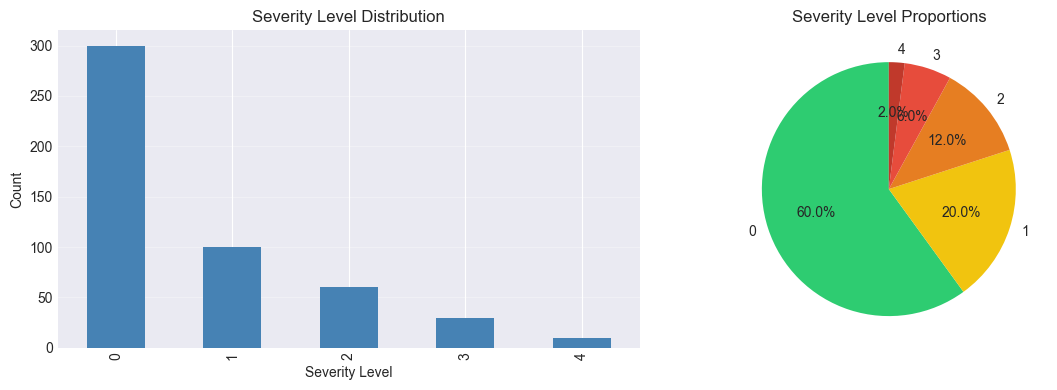


🔍 STEP 4: Missing Value Analysis

🔍 MISSING VALUE ANALYSIS

1. Columns with missing values:
  Column  Missing_Count  Missing_Percent
   P12_x            405             81.0
   P12_y            405             81.0
P12_conf            405             81.0
    P5_y             64             12.8
    P5_x             64             12.8
 P5_conf             64             12.8
    P3_y             62             12.4
    P3_x             62             12.4
 P3_conf             62             12.4
    P9_y             53             10.6

2. Missing pattern by joint points:
   P12:  81.0% ████████████████████████████████████████
   P5 :  12.8% ██████
   P3 :  12.4% ██████
   P0 :  10.6% █████
   P9 :  10.6% █████
   P4 :  10.4% █████
   P11:  10.4% █████
   P7 :  10.2% █████
   P1 :  10.0% █████
   P2 :   9.4% ████
   P8 :   9.4% ████
   P6 :   9.0% ████
   P10:   9.0% ████


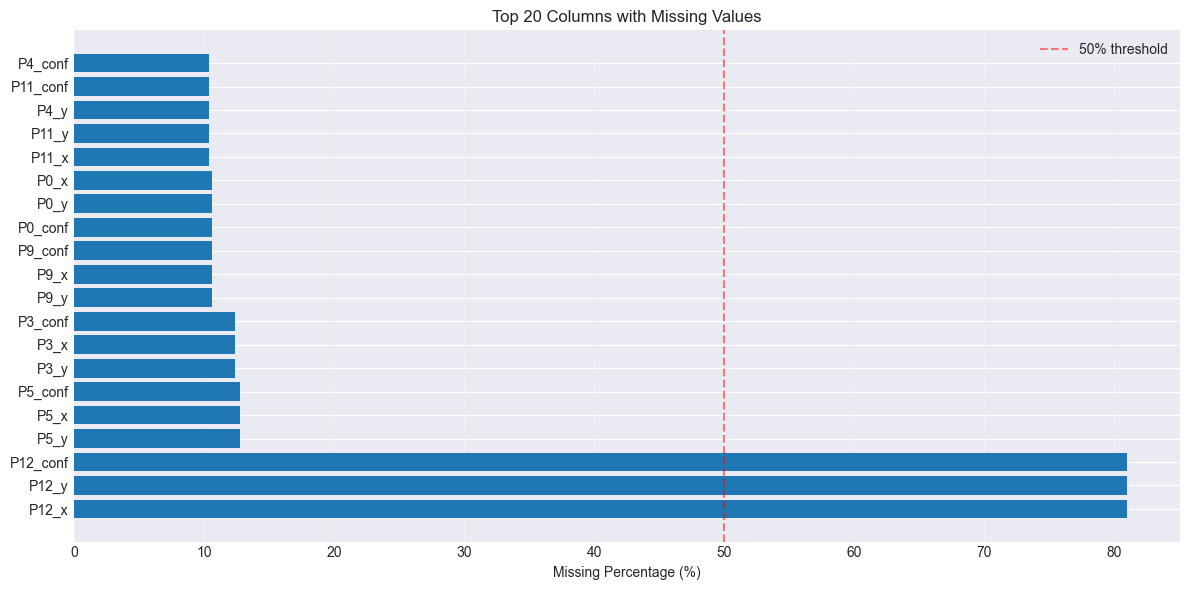


📈 STEP 5: Feature Statistics

📈 FEATURE STATISTICS

1. Pet Information Statistics:
              age      weight
count  500.000000  500.000000
mean     8.110000   26.685141
std      4.486665   13.125226
min      1.000000    5.009628
25%      4.000000   15.321912
50%      8.000000   26.627821
75%     12.000000   37.217545
max     15.000000   49.779786

2. Breed Distribution:
   Dachshund           :  68 ( 13.6%)
   Golden Retriever    :  63 ( 12.6%)
   Yorkshire Terrier   :  61 ( 12.2%)
   Siberian Husky      :  47 (  9.4%)
   Boxer               :  47 (  9.4%)
   Beagle              :  46 (  9.2%)
   Labrador            :  44 (  8.8%)
   Poodle              :  43 (  8.6%)
   Bulldog             :  42 (  8.4%)
   German Shepherd     :  39 (  7.8%)

3. Sensor Data Statistics:
       acc_x_mean  acc_y_mean  acc_z_mean  gyro_x_mean  gyro_y_mean  \
count  500.000000  500.000000  500.000000   500.000000   500.000000   
mean     0.000301   -0.005721    9.793937    -0.000642    -0.005544   
s

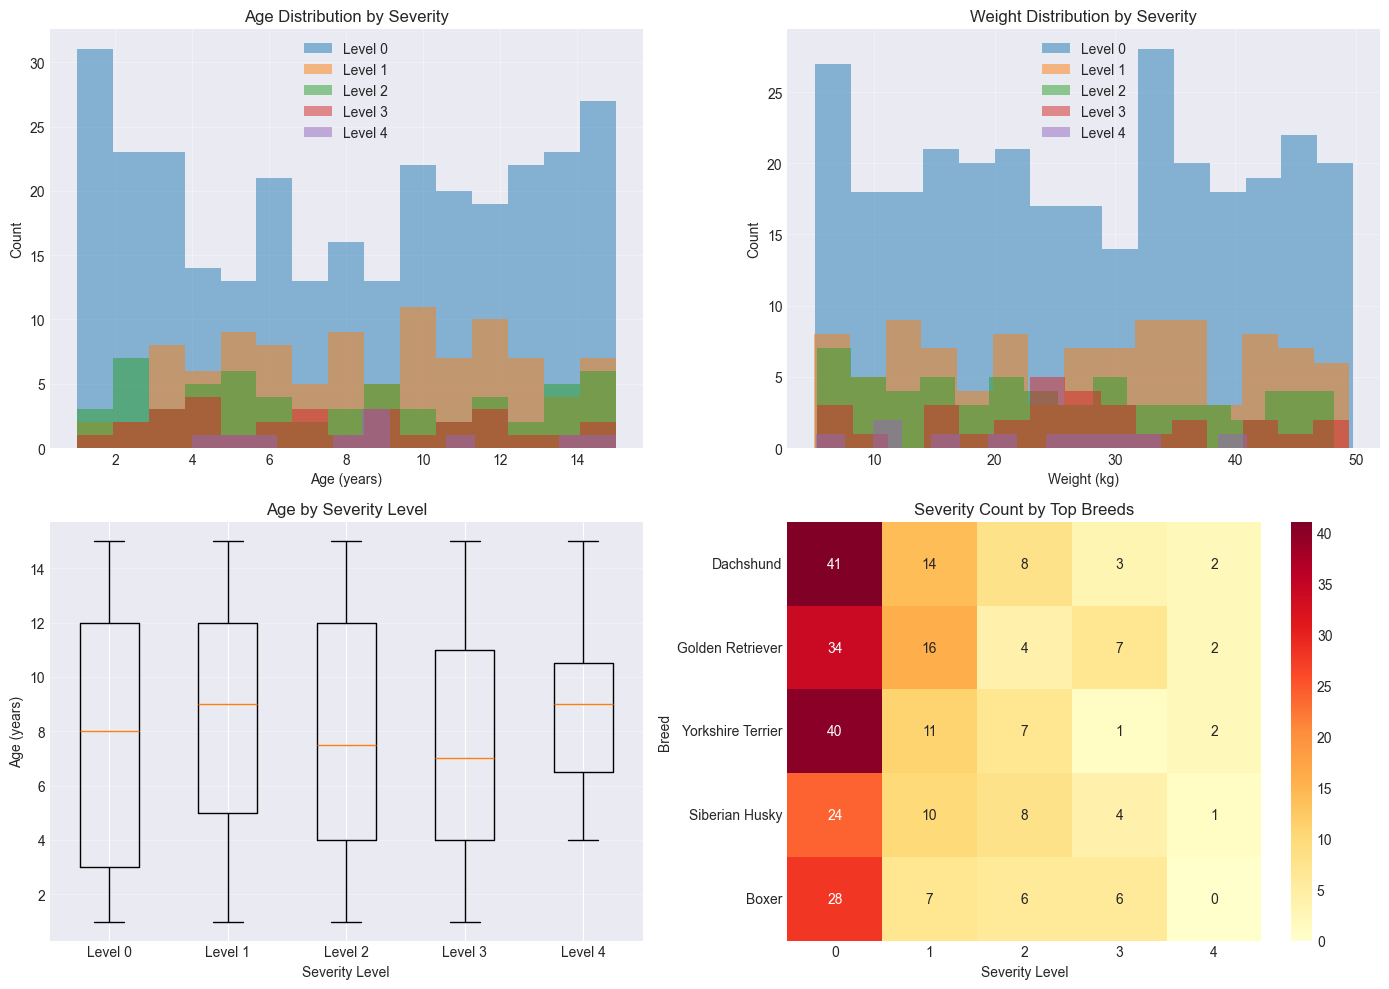


🔗 STEP 7: Correlation Analysis

🔗 CORRELATION ANALYSIS

1. Top 15 Features Correlated with Severity:
   (Positive = increases with severity)
   gyro_x_std          : +0.975 ███████████████████
   gyro_z_std          : +0.975 ███████████████████
   gyro_y_std          : +0.972 ███████████████████
   acc_z_std           : +0.961 ███████████████████
   acc_y_std           : +0.960 ███████████████████
   acc_x_std           : +0.959 ███████████████████
   gyro_x_max          : +0.878 █████████████████
   gyro_z_max          : +0.874 █████████████████
   gyro_y_max          : +0.860 █████████████████
   acc_z_max           : +0.828 ████████████████
   acc_x_max           : +0.800 ████████████████
   acc_y_max           : +0.791 ███████████████
   P12_x               : +0.208 ████
   P10_y               : +0.156 ███
   P7_x                : +0.137 ██

2. Bottom 15 Features (Negative Correlation):
   P8_conf             : -0.758 ███████████████
   P3_conf             : -0.760 ███████████████

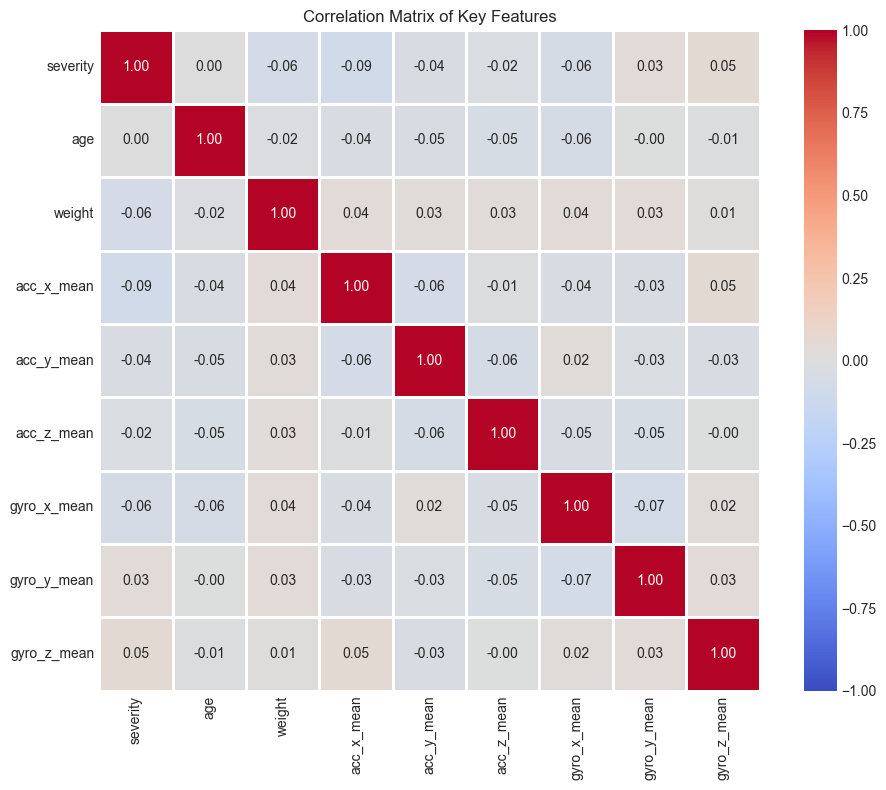


🦴 STEP 8: Pose Feature Analysis

🦴 POSE FEATURE ANALYSIS

1. Average Confidence by Joint:
   P12: 0.789 ███████████████████████████████████████
   P9 : 0.788 ███████████████████████████████████████
   P11: 0.786 ███████████████████████████████████████
   P7 : 0.786 ███████████████████████████████████████
   P3 : 0.784 ███████████████████████████████████████
   P10: 0.784 ███████████████████████████████████████
   P5 : 0.784 ███████████████████████████████████████
   P2 : 0.783 ███████████████████████████████████████
   P8 : 0.782 ███████████████████████████████████████
   P4 : 0.778 ██████████████████████████████████████
   P0 : 0.777 ██████████████████████████████████████
   P6 : 0.777 ██████████████████████████████████████
   P1 : 0.776 ██████████████████████████████████████

2. Joint Position Variability (std) by Severity:
   Level 0: X-std=9.98, Y-std=9.93
   Level 1: X-std=14.36, Y-std=14.32
   Level 2: X-std=20.63, Y-std=19.76
   Level 3: X-std=25.03, Y-std=23.72
   Level 4: X-s

In [8]:
# ================== 실행 ==================

if __name__ == "__main__":
    # EDA 실행
    df, raw_data = run_complete_eda()
    
    # 추가 분석을 위한 데이터 저장
    print("\n💾 Saving processed data...")
    df.to_csv('pet_data_processed.csv', index=False)
    print("✅ Saved to 'pet_data_processed.csv'")
    
    # 다음 단계 안내
    print("\n📌 Next Steps:")
    print("1. Feature Engineering based on insights")
    print("2. Handle class imbalance")
    print("3. Build and evaluate models")
    print("4. Optimize for medical use case")

### 🎯 분석 프로세스

1. 데이터 생성 및 로드 → 현실적인 샘플 데이터 자동 생성
2. 기본 구조 파악 → 데이터 크기, 타입, 메모리 사용량
3. 타겟 변수 분석 → 중증도 분포, 클래스 불균형
4. 결측치 패턴 → 어떤 관절이 자주 가려지는지
5. 피처별 통계 → 나이, 체중, 센서값 분포
6. 중증도별 특성 → 심한 경우와 경미한 경우의 차이
7. 상관관계 분석 → 어떤 피처가 중요한지
8. 통계적 검정 → 유의미한 차이가 있는지
9. 인사이트 도출 → 모델링 전략 수립

### 📈 주요 특징

- 현실적인 샘플 데이터: 품종별 특성, 나이별 위험도 반영
- 시각화 포함: 분포, 상관관계, 박스플롯 등
- 통계 검정: Kruskal-Wallis, Chi-square 검정
- 실행 가능한 인사이트: 구체적인 다음 단계 제시

### 💡 예상 발견사항

1. 클래스 불균형: Level 0 (정상)이 50%, Level 4 (심각)는 3% 정도
2. P12 결측치: 꼬리 끝 관절은 70% 이상 missing
3. 나이와 중증도: 나이가 많을수록 중증도 증가 경향
4. 품종별 차이: Bulldog, German Shepherd가 고위험군
5. 센서 패턴: 중증도 높을수록 불규칙한 움직임

### 📝 분석 후 다음 단계

1. 어떤 피처가 중요한지
2. 어떤 전처리가 필요한지
3. 어떤 모델이 적합한지